## Read and format data

In [90]:
from datetime import datetime, date 

In [91]:
from pathlib import Path

def collect_lines_from_txt(txt_file: str) -> list:
    results = list()
    print(f"Processing file: {txt_file}")
    with Path(txt_file).open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.rstrip("\n")
            if 'cycle' in line:
                l = next(handle).rstrip("\n")
                l = l.replace("Period start date: ", "")
                results.append(datetime.strptime(l, "%Y-%m-%d %H:%M:%S.%f").date())
    return results

In [92]:
cycles = collect_lines_from_txt("C:\\Users\\kikka\\Documents\\Projects\\poc_cycle\\data\\res.txt")

Processing file: C:\Users\kikka\Documents\Projects\poc_cycle\data\res.txt


In [93]:
cycles[0]

datetime.date(2016, 5, 14)

In [94]:
len(cycles)

119

In [95]:
# Add recent points
more_dates = list([date(2025, 9, 15), date(2025, 10, 13), date(2025, 11, 8), date(2025, 12, 5), date(2026, 1, 5), date(2026, 1, 31), date(2026, 2, 25), date(2026, 3, 23), date(2026, 4, 18), date(2026, 5, 18), date(2026, 6, 13)])
cycles.extend(more_dates)

In [96]:
cycles[-1]

datetime.date(2026, 6, 13)

In [97]:
import pandas as pd 
cycles_df = pd.DataFrame(cycles, columns=['date'])
cycles_df.to_csv("C:\\Users\\kikka\\Documents\\Projects\\poc_cycle\\data\\cycles.csv", index=False)

# EDA

In [98]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot

In [99]:
cycles_df.date = pd.to_datetime(cycles_df.date)

In [100]:
cycles_df 

,date
0,2016-05-14
1,2016-06-10
2,2016-07-06
3,2016-07-28
4,2016-08-22
...,...
125,2026-02-25
126,2026-03-23
127,2026-04-18
128,2026-05-18


In [101]:
cycles_df["cycle_id"] = cycles_df.index

In [102]:
cycles_df.set_index("date", inplace=True)

In [103]:
cycles_df['year'] = cycles_df.index.year
cycles_df['month'] = cycles_df.index.month
cycles_df['day'] = cycles_df.index.day

In [104]:
cycles_df

,cycle_id,year,month,day
date,,,,
2016-05-14,0,2016,5,14
2016-06-10,1,2016,6,10
2016-07-06,2,2016,7,6
2016-07-28,3,2016,7,28
2016-08-22,4,2016,8,22
...,...,...,...,...
2026-02-25,125,2026,2,25
2026-03-23,126,2026,3,23
2026-04-18,127,2026,4,18


In [105]:
cycles_df['cycle_duration'] = cycles_df.index.to_series().diff().shift(-1).dt.days

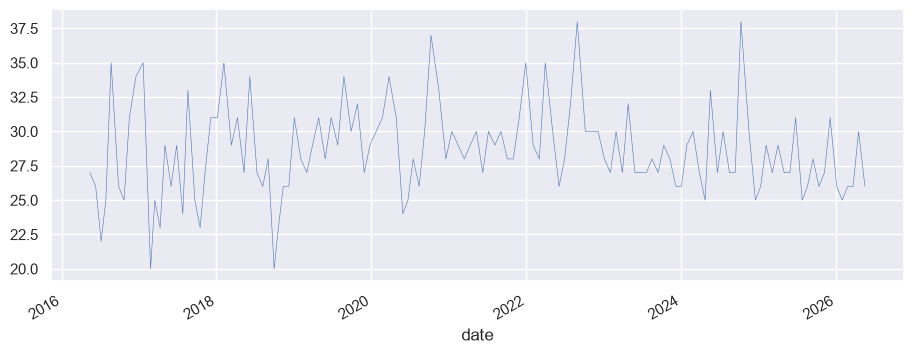

In [106]:
# Use seaborn style defaults and set the default figure size
sns.set(rc={'figure.figsize':(11, 4)})
cycles_df['cycle_duration'].plot(linewidth=0.4);

In [88]:
cycles_df.to_csv("C:\\Users\\kikka\\Documents\\Projects\\poc_cycle\\data\\cycles_with_durations.csv", index=False)

In [107]:
cycles_df['date'] = pd.to_datetime(cycles_df.index, format='%Y-%m-%d')

In [108]:
cycles_df.index = cycles_df['cycle_id']

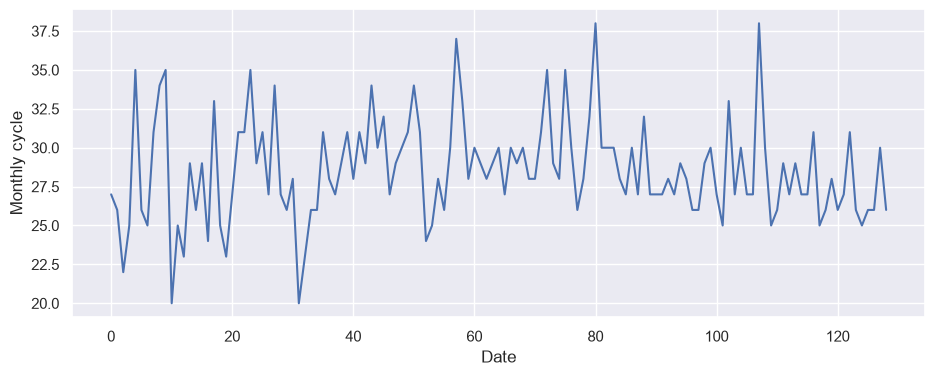

In [109]:
cycles_df['cycle_duration'].plot()
plt.ylabel('Monthly cycle')
plt.xlabel('Date')
plt.show()

In [110]:
from typing import Tuple

def append_lag_features(data: pd.DataFrame, window: int) -> pd.DataFrame:
    if "cycle_duration" not in data.columns:
        raise ValueError("Data must contain a cycle_duration column")
    if len(data) <= window:
        raise ValueError("Not enough points to create lag features")

    lagged = data.copy()
    for lag in range(1, window + 1):
        lagged[f"lag_{lag}"] = lagged["cycle_duration"].shift(lag)
    return lagged

def build_features(data: pd.DataFrame, window: int) -> Tuple[pd.DataFrame, np.ndarray]:
    if len(data) <= window:
        raise ValueError("Not enough points to create lag features")

    lagged = append_lag_features(data, window)
    feature_cols = ["cycle_id", "year", "month", "day", 'date'] + [f"lag_{i}" for i in range(1, window + 1)]
    x = lagged.loc[window:, feature_cols] #.to_numpy(dtype=float)
    y = lagged.loc[window:, "cycle_duration"].fillna(0).to_numpy(dtype=float)
    return x, y

In [111]:
X, y = build_features(cycles_df, 5)
X_tr = X.loc[X['year'] < 2026]
X_test = X.loc[X['year'] >= 2026]
y_tr = y[X['year'] < 2026]
y_test = y[X['year'] >= 2026]

In [112]:
# Define the d and q parameters to take any value between 0 and 1
import itertools


q = d = range(0, 2)
# Define the p parameters to take any value between 0 and 3
p = range(0, 4)

# Generate all different combinations of p, q and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, q and q triplets
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


In [113]:
import warnings 
import statsmodels.api as sm
warnings.filterwarnings("ignore") # specify to ignore warning messages

AIC = []
SARIMAX_model = []
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False,
                                            endog=y_tr)

            results = mod.fit()

            print('SARIMAX{}x{} - AIC:{}'.format(param, param_seasonal, results.aic), end='\r')
            AIC.append(results.aic)
            SARIMAX_model.append([param, param_seasonal])
        except Exception as e:
            print(e)
            continue

In [114]:
print('The smallest AIC is {} for model SARIMAX{}x{}'.format(min(AIC), SARIMAX_model[AIC.index(min(AIC))][0],SARIMAX_model[AIC.index(min(AIC))][1]))

The smallest AIC is 350.6557929516233 for model SARIMAX(3, 1, 1)x(3, 1, 0, 12)


In [115]:
# Let's fit this model
mod = sm.tsa.statespace.SARIMAX(y_tr,
                                order=SARIMAX_model[AIC.index(min(AIC))][0],
                                seasonal_order=SARIMAX_model[AIC.index(min(AIC))][1],
                                enforce_stationarity=False,
                                enforce_invertibility=False)

results = mod.fit()

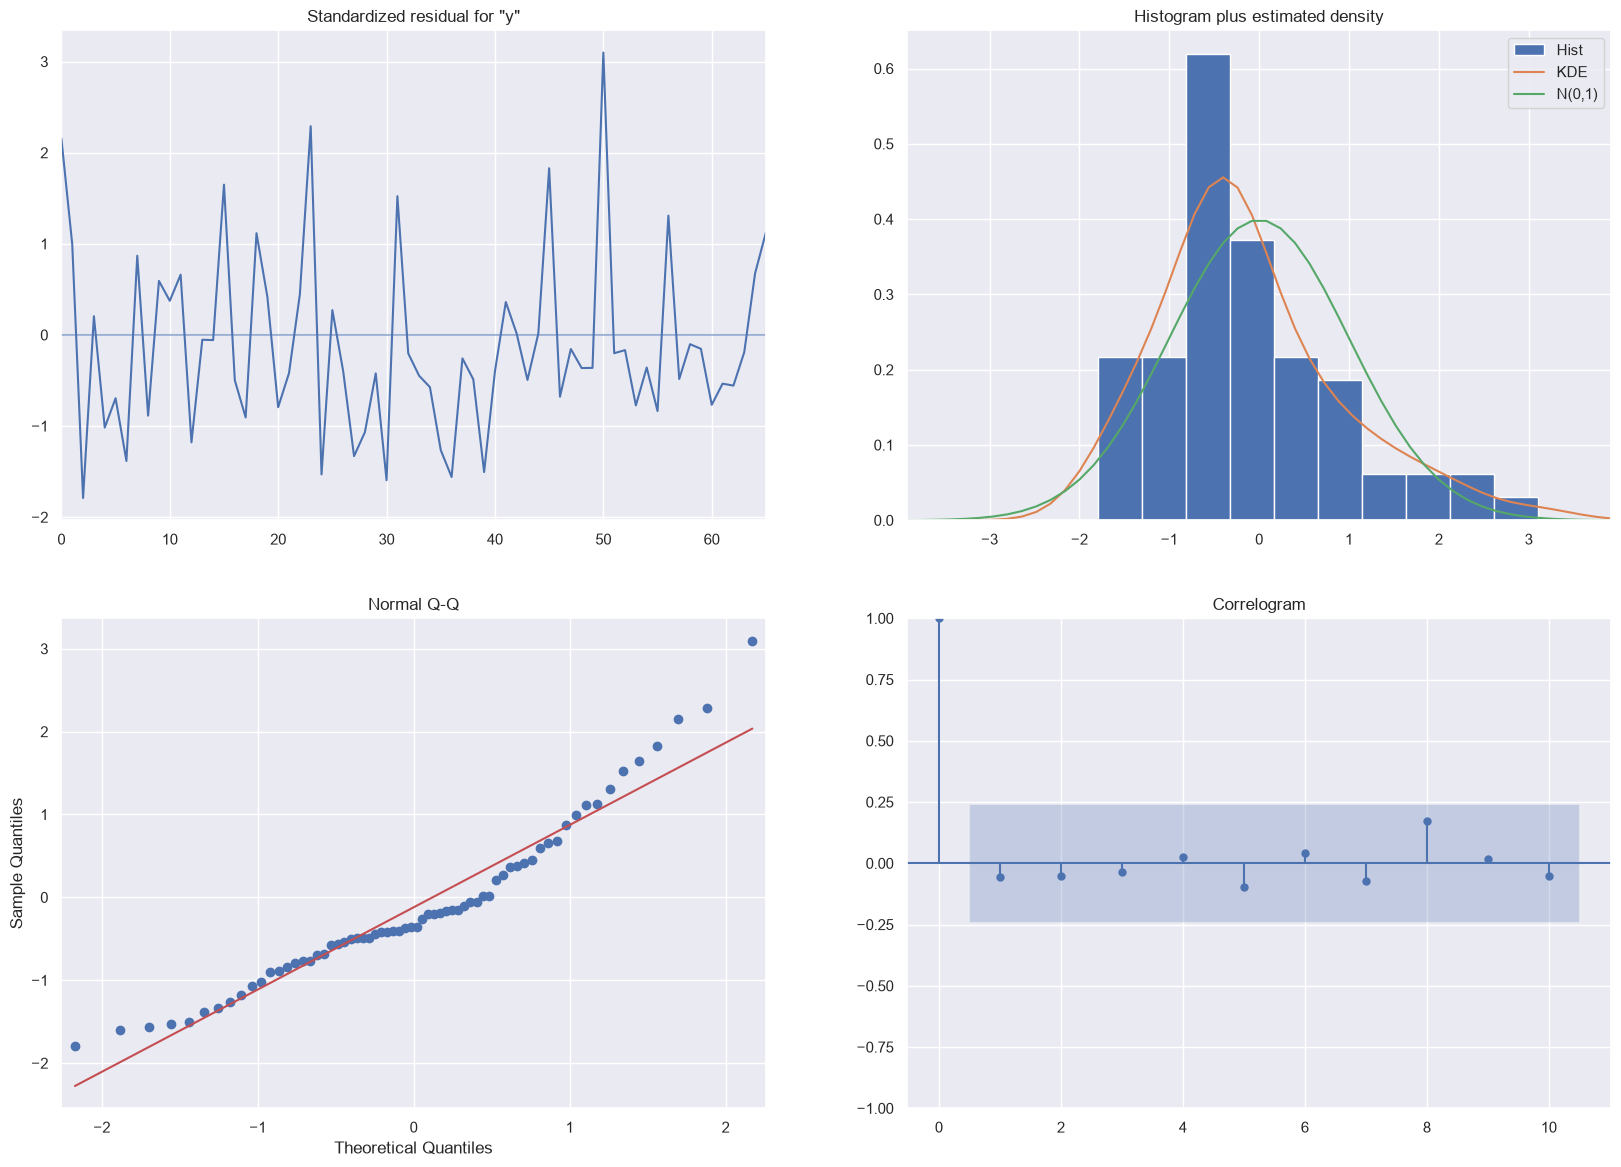

In [116]:
results.plot_diagnostics(figsize=(20, 14))
plt.show()

In [117]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  118
Model:             SARIMAX(3, 1, 1)x(3, 1, [], 12)   Log Likelihood                -167.328
Date:                             Sat, 27 Jun 2026   AIC                            350.656
Time:                                     13:01:57   BIC                            368.173
Sample:                                          0   HQIC                           357.578
                                             - 118                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0583      0.193      0.303      0.762      -0.319       0.436
ar.L2         -0.1783      0.202     -0.883      0.377      -0.574       0.217
ar.L3          0.0214      0.173      0.123      0.902      -0.319       0.361
ma.L1         -0.9032      0.096     -9.392      0.000      -1.092      -0.715
ar.S.L12      -0.8089      0.133     -6.073      0.000      -1.070      -0.548
ar.S.L24      -0.4259      0.162     -2.633      0.008      -0.743      -0.109
ar.S.L36      -0.0448      0.134     -0.334      0.738      -0.308       0.218
sigma2         9.2322      1.695      5.446      0.000       5.909      12.555
===================================================================================
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):                11.56
Prob(Q):                              0.63   Prob(JB):                         0.00
Heteroskedasticity (H):               0.91   Skew:                             0.93
Prob(H) (two-sided):                  0.82   Kurtosis:                         3.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [168]:
predictions = []
for date in ['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', '2026-06-01']:
    pred2 = results.get_forecast(date=date)
    pred2_ci = pred2.conf_int()
    predictions.append(np.float64(pred2.predicted_mean))
    print(f"Predicted cycle duration for {date}: {pred2.predicted_mean} days")

Predicted cycle duration for 2026-01-01: [27.68382888] days
Predicted cycle duration for 2026-02-01: [27.68382888] days
Predicted cycle duration for 2026-03-01: [27.68382888] days
Predicted cycle duration for 2026-04-01: [27.68382888] days
Predicted cycle duration for 2026-05-01: [27.68382888] days
Predicted cycle duration for 2026-06-01: [27.68382888] days


In [171]:
# flatten nested list
MAPE = []
truth = y_test.tolist()[:-1]
# Mean Absolute Percentage Error
for i in range(len(truth)):
    print(f"Truth: {truth[i]}, Prediction: {predictions[i]}")
    mape = np.mean(np.abs((truth[i] - predictions[i]) / truth[i])) * 100
    MAPE.append(mape)
MAPE = np.mean(MAPE)

print('The Mean Absolute Percentage Error for the forecast of year 2026 is {:.2f}%'.format(MAPE))

Truth: 26.0, Prediction: [27.68382888]
Truth: 25.0, Prediction: [27.68382888]
Truth: 26.0, Prediction: [27.68382888]
Truth: 26.0, Prediction: [27.68382888]
Truth: 30.0, Prediction: [27.68382888]
Truth: 26.0, Prediction: [27.68382888]
The Mean Absolute Percentage Error for the forecast of year 2026 is 7.39%


In [172]:
truth

[26.0, 25.0, 26.0, 26.0, 30.0, 26.0]

In [173]:
predictions

[array([27.68382888]),
 array([27.68382888]),
 array([27.68382888]),
 array([27.68382888]),
 array([27.68382888]),
 array([27.68382888])]